# 서울 기온이 의류소비에 미치는 영향 분석

- **분석 기간**: 2019-01 ~ 2024-12 (72개월)
- **데이터 출처**:
  - 기온: 기상청 기상자료개방포털 (서울, 지점 108, 월평균)
  - 의류판매: KOSIS 국가통계포털 (소매판매지수, 의복, 2020=100)
  - 검색량: 네이버 데이터랩 (겨울옷/여름옷/봄옷 키워드, 일별→월평균)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
import csv

# 한글 폰트 설정
# - Windows: 'Malgun Gothic'
# - Mac: 'AppleGothic'
# - Linux(본 실행 환경): 'Noto Sans CJK JP'
plt.rcParams['font.family'] = 'Noto Sans CJK JP'   # Windows라면 'Malgun Gothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False


## STEP 1. 기온 데이터 로딩 (월별)

In [ ]:
temp = pd.read_csv('data/기온_월별.csv', encoding='utf-8-sig')
temp.columns = ['년월', '지점', '평균기온', '평균최저기온', '평균최고기온']
temp['년월'] = pd.to_datetime(temp['년월'], format='%Y-%m')
temp = temp[['년월', '평균기온', '평균최저기온', '평균최고기온']]

print(temp.shape)
print(temp.isnull().sum())
temp.head()


(72, 4)
년월        0
평균기온      0
평균최저기온    0
평균최고기온    0
dtype: int64


## STEP 2. 검색량 데이터 로딩 (일별 → 월평균 변환)

In [ ]:
raw = pd.read_csv('data/검색량.csv', encoding='utf-8-sig', header=None, skiprows=6)
raw.columns = ['날짜1', '겨울옷', '날짜2', '여름옷', '날짜3', '봄옷']
raw['날짜1'] = pd.to_datetime(raw['날짜1'])
raw['년월'] = raw['날짜1'].dt.to_period('M').dt.to_timestamp()

search_monthly = raw.groupby('년월')[['겨울옷', '여름옷', '봄옷']].mean().reset_index()

print(search_monthly.shape)
print(search_monthly.isnull().sum())
search_monthly.head()


(72, 4)
년월     0
겨울옷    0
여름옷    0
봄옷     0
dtype: int64


## STEP 3. 의류판매 데이터 로딩

원본이 가로형(월이 열 방향)이라 `csv.reader`로 직접 읽어 '의복' 행만 뽑고,
'경상지수' 컬럼만 사용해 세로형(월별 1개 값)으로 변환한다.

In [ ]:
with open('data/의류판매.csv', encoding='cp949', newline='') as f:
    rows = list(csv.reader(f))

months = rows[0][1:]      # ['2019.01', '2019.01', '2019.01', '2019.02', ...]
metrics = rows[1][1:]     # ['경상지수', '불변지수', '계절조정지수', ...]
target_row = [r for r in rows[2:] if r[0] == '의복'][0]
values = target_row[1:]

df = pd.DataFrame({'년월_raw': months, '지표': metrics, '값': values})
df['값'] = pd.to_numeric(df['값'], errors='coerce')

clothing = df[df['지표'] == '경상지수'].copy()
clothing['년월'] = pd.to_datetime(clothing['년월_raw'], format='%Y.%m')
clothing = clothing[['년월', '값']].rename(columns={'값': '의복판매지수'})
clothing = clothing.sort_values('년월').reset_index(drop=True)

print(clothing.shape)
print(clothing.isnull().sum())
clothing.head()


(72, 2)
년월        0
의복판매지수    0
dtype: int64


## STEP 4. 3개 데이터 통합 (2019~2024)

In [ ]:
merged = temp.merge(search_monthly, on='년월').merge(clothing, on='년월')
merged = merged.sort_values('년월').reset_index(drop=True)

def get_season(m):
    if m in [3, 4, 5]:
        return '봄'
    elif m in [6, 7, 8]:
        return '여름'
    elif m in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

merged['계절'] = merged['년월'].dt.month.apply(get_season)
merged['월'] = merged['년월'].dt.month
merged['년'] = merged['년월'].dt.year

print('최종 통합 데이터:', merged.shape)
print('결측치:')
print(merged.isnull().sum())
merged.head()


최종 통합 데이터: (72, 11)
결측치:
년월        0
평균기온      0
평균최저기온    0
평균최고기온    0
겨울옷       0
여름옷       0
봄옷        0
의복판매지수    0
계절        0
월         0
년         0
dtype: int64


## 시계열 분석 기법 적용: 이동평균 / 전월대비 증감률

In [ ]:
merged['의복판매지수_3개월이동평균'] = merged['의복판매지수'].rolling(3).mean()
merged['의복판매지수_전월대비증감률(%)'] = merged['의복판매지수'].pct_change() * 100

merged[['년월', '의복판매지수', '의복판매지수_3개월이동평균', '의복판매지수_전월대비증감률(%)']].tail(8)


           년월  의복판매지수  의복판매지수_3개월이동평균  의복판매지수_전월대비증감률(%)
64 2024-05-01   140.4          141.47               -0.64
65 2024-06-01   131.1          137.60               -6.62
66 2024-07-01   116.6          129.37              -11.06
67 2024-08-01   102.4          116.70              -12.18
68 2024-09-01   121.0          113.33               18.16
69 2024-10-01   157.3          126.90               30.00
70 2024-11-01   168.0          148.77                6.80
71 2024-12-01   155.2          160.17               -7.62


## 시각화 1. 기온 & 의류판매지수 이중축 시계열

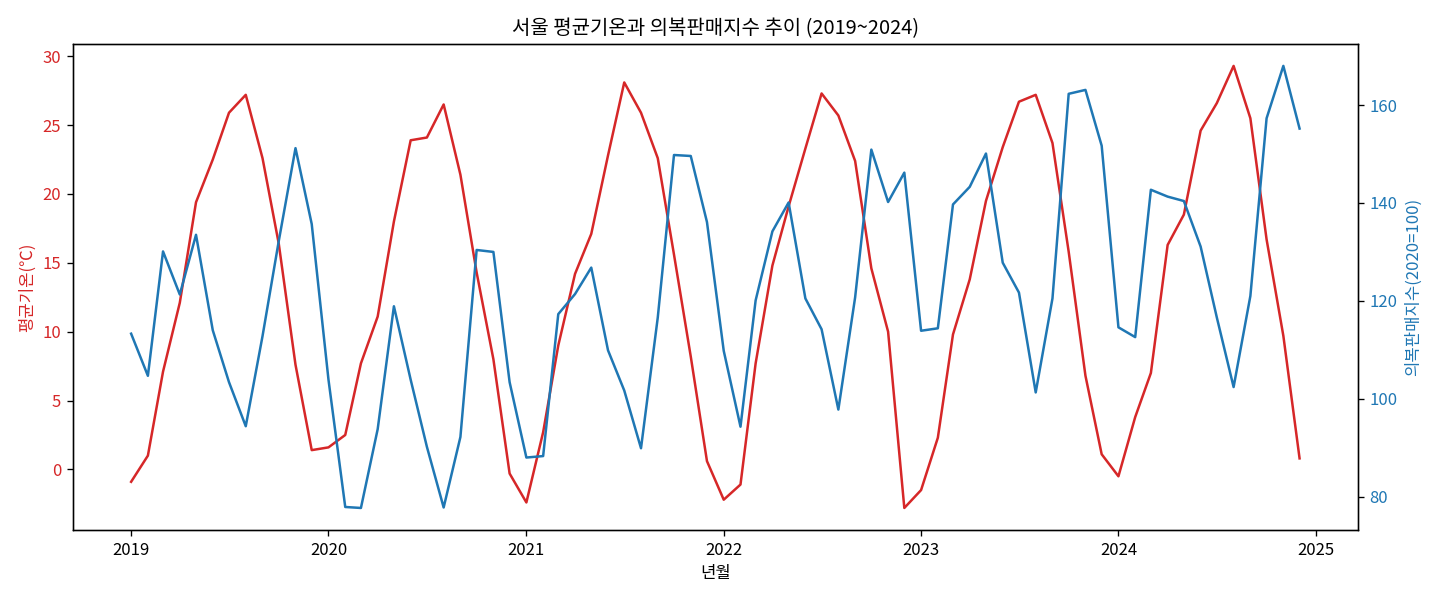

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(merged['년월'], merged['평균기온'], color='tab:red', label='평균기온(℃)')
ax1.set_xlabel('년월')
ax1.set_ylabel('평균기온(℃)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(merged['년월'], merged['의복판매지수'], color='tab:blue', label='의복판매지수')
ax2.set_ylabel('의복판매지수(2020=100)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('서울 평균기온과 의복판매지수 추이 (2019~2024)')
fig.tight_layout()
plt.savefig('charts/01_temp_vs_clothing.png', dpi=120)
plt.show()


**관찰**: 기온과 의복판매지수는 뚜렷한 계절 사이클을 보이지만, 두 곡선의 봉우리/골짜기 시점이 정확히 겹치지 않고 어긋나 있다. (→ 시각화 2에서 정량적으로 확인)

## 시각화 2. 계절별 기온 vs 의복판매지수 산점도 + 회귀선

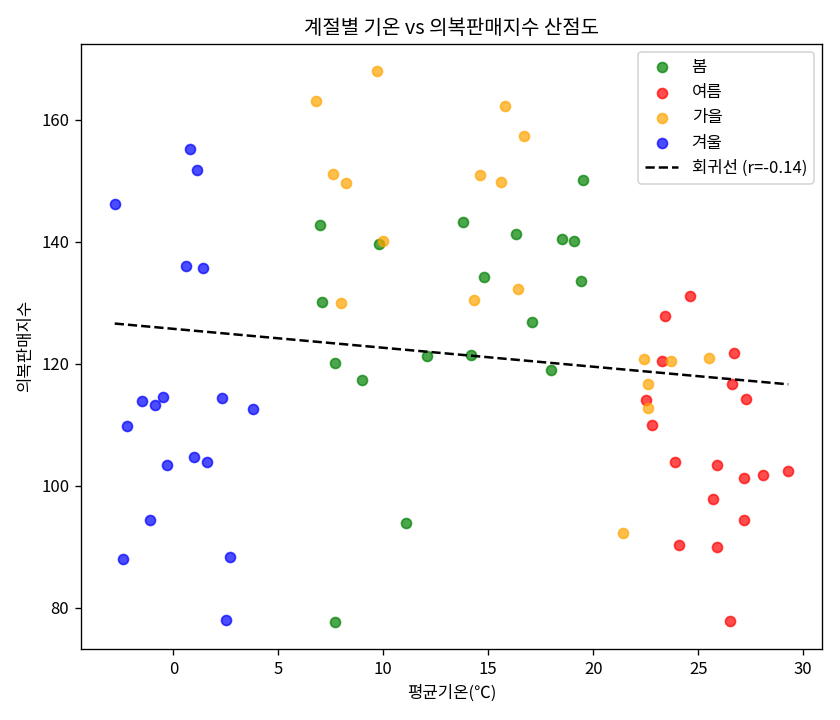

전체 회귀: r=-0.139, p=0.2429


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
season_colors = {'봄': 'green', '여름': 'red', '가을': 'orange', '겨울': 'blue'}
for season, color in season_colors.items():
    sub = merged[merged['계절'] == season]
    ax.scatter(sub['평균기온'], sub['의복판매지수'], color=color, label=season, alpha=0.7)

slope, intercept, r_value, p_value, std_err = stats.linregress(merged['평균기온'], merged['의복판매지수'])
x_line = np.linspace(merged['평균기온'].min(), merged['평균기온'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', label=f'회귀선 (r={r_value:.2f})')

ax.set_xlabel('평균기온(℃)')
ax.set_ylabel('의복판매지수')
ax.set_title('계절별 기온 vs 의복판매지수 산점도')
ax.legend()
fig.tight_layout()
plt.savefig('charts/02_seasonal_scatter.png', dpi=120)
plt.show()

print(f'전체 회귀: r={r_value:.3f}, p={p_value:.4f}')


**관찰**: 당월 기온과 의복판매지수의 전체 상관은 약하고 통계적으로 유의하지 않다(r=-0.14, p=0.24). 겨울(파랑)이 전반적으로 판매지수 분산이 크고, 가을(주황)에 고점이 몰려 있다.

## 시각화 3. 연도별-월별 의복판매지수 패턴 (히트맵)

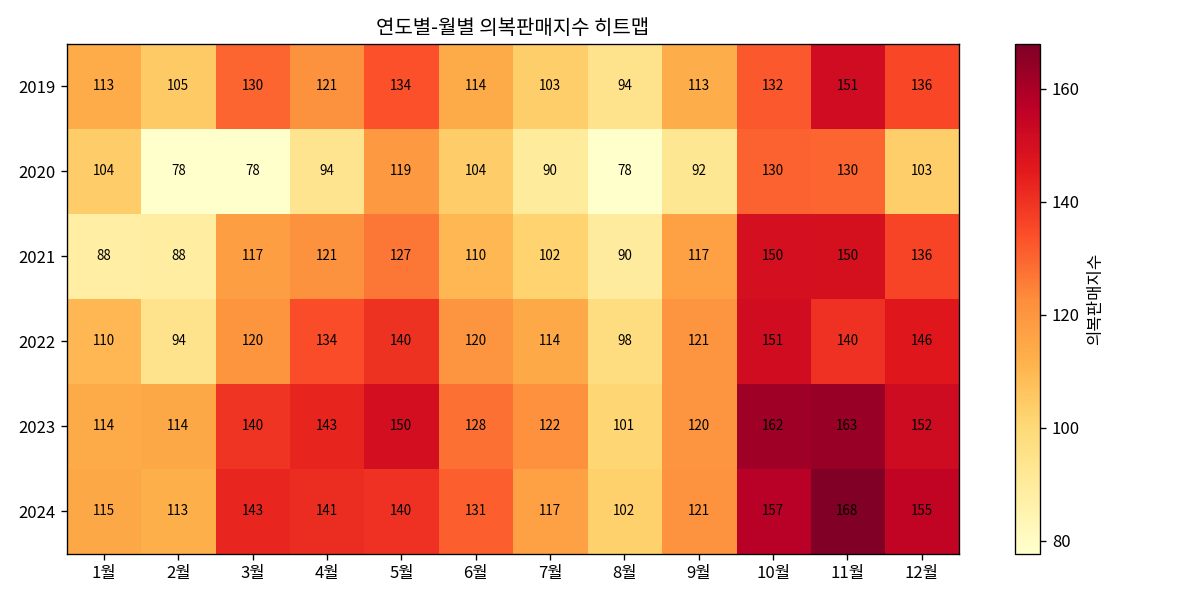

In [ ]:
pivot = merged.pivot_table(index='년', columns='월', values='의복판매지수')

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(12))
ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('연도별-월별 의복판매지수 히트맵')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='의복판매지수')
fig.tight_layout()
plt.savefig('charts/03_monthly_heatmap.png', dpi=120)
plt.show()


**관찰**: 매년 10~11월이 가장 진하고(고점), 8월이 가장 연하다(저점). 2020년은 전 월에 걸쳐 다른 해보다 색이 옅다(코로나19 영향 추정 — 추가 검증 필요).

## 상관분석 (Pearson r, p-value)

In [ ]:
print('=== 상관분석 (전체 72개월) ===')
for col in ['평균기온', '겨울옷', '여름옷', '봄옷']:
    r, p = stats.pearsonr(merged[col], merged['의복판매지수'])
    print(f'{col} vs 의복판매지수: r={r:.3f}, p={p:.4f}')


=== 상관분석 (전체 72개월) ===
평균기온 vs 의복판매지수: r=-0.139, p=0.2429
겨울옷 vs 의복판매지수: r=0.439, p=0.0001
여름옷 vs 의복판매지수: r=-0.130, p=0.2769
봄옷 vs 의복판매지수: r=0.025, p=0.8372


**관찰**: 당월 기온 자체보다, '겨울옷' 검색량이 의복판매지수와 더 강하고 유의한 양의 상관(r=0.44, p<0.001)을 보인다. 반면 '여름옷', '봄옷' 검색량은 유의한 상관이 없다.

**해석(가설, 검증 필요)**: 옷 구매는 '그날 기온'보다 '겨울이 다가온다는 계절 인지·선제적 준비 행동(검색)'과 더 밀접하게 연동될 수 있다. 다만 이는 상관관계이며 인과관계를 의미하지 않는다.

---
*(다음 단계: 인사이트 3개 이상 정리, REPORT.md 작성, requirements.txt 작성, GitHub 업로드)*